<a href="https://colab.research.google.com/github/APES-M-JeissonS-JuanB/Sesion_1_Aprendizaje_Estadistico_Analisis_Descriptivo/blob/main/Sanchez_Jeisson_y_Bogota_Juan_CasoEstudio_sesion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso de estudio integrador - Sesión 1**
### **RutaExpress: análisis descriptivo de una operación de última milla**
**Estudiantes:** *Jeisson David Sanchez & Juan Daniel Bogotá*


## **1. Contexto de negocio**

RutaExpress es una startup de entregas de última milla (last-mile delivery) que acaba de cerrar una ronda de inversión Serie A. Opera con una flota mixta de bicicletas, motocicletas, automóviles y, de forma piloto, drones de reparto en algunas zonas de la ciudad.

La Dirección de Operaciones te contrata como analista de datos para responder, con evidencia estadística, tres preguntas que están sobre la mesa del comité directivo:
* ¿Vale la pena invertir en expandir la flota de drones más allá del piloto
actual?
* ¿Qué zona de la ciudad requiere una intervención operativa prioritaria?
* ¿Qué meta de tiempo de entrega (SLA) es razonable comunicar públicamente a los clientes, sin comprometer la reputación de la marca?

Para resolverlas, el equipo de operaciones te compartió un extracto de 1,500 envíos recientes con información de zona, vehículo, nivel de servicio, distancia, peso, tiempo de entrega, incidencias, calificación del cliente y costo.


## **2. Diccionario de datos**
La siguiente tabla describe cada variable del dataset. Nota que, deliberadamente, no se incluye una columna de "tipo de variable": clasificarlas es parte de tu trabajo en la Parte A.

| Variable                | Descripción                                                                                                | Unidad / Categorías                     |
| ----------------------- | ---------------------------------------------------------------------------------------------------------- | --------------------------------------- |
| envio_id                | Identificador único del envío                                                                              | Numérico secuencial (no analizar)       |
| zona_entrega            | Zona de la ciudad donde se entregó el paquete                                                              | Centro, Norte, Sur, Poniente, Oriente   |
| tipo_vehiculo           | Vehículo usado para realizar la entrega                                                                    | Bicicleta, Motocicleta, Automóvil, Dron |
| nivel_servicio          | Nivel de servicio contratado por el cliente                                                                | Estándar, Prioritario, Express          |
| distancia_km            | Distancia recorrida entre el centro de distribución y el destino                                           | Kilómetros                              |
| peso_paquete_kg         | Peso del paquete entregado                                                                                 | Kilogramos                              |
| tiempo_entrega_min      | Tiempo total transcurrido desde que el paquete sale del centro de distribución hasta que llega al cliente  | Minutos                                 |
| paquetes_repartidor_dia | Número de paquetes que entregó ese repartidor durante el día del envío                                     | Conteo de paquetes                      |
| incidencias_reportadas  | Número de incidencias registradas durante ese envío (tráfico, dirección incorrecta, cliente ausente, etc.) | Conteo de incidencias                   |
| calificacion_cliente    | Calificación que el cliente dio al servicio recibido                                                       | Escala de 1 a 5 estrellas               |
| costo_envio_mxn         | Costo total cobrado al cliente por el envío                                                                | Pesos mexicanos (MXN)                   |


## **3. Generación de los datos**


In [24]:
import numpy as np
import pandas as pd

np.random.seed(2026)
n_envios = 1500

zona_entrega = np.random.choice(
    ["Centro", "Norte", "Sur", "Poniente", "Oriente"],
    size=n_envios, p=[0.30, 0.20, 0.20, 0.15, 0.15]
)

tipo_vehiculo = np.random.choice(
    ["Bicicleta", "Motocicleta", "Automóvil", "Dron"],
    size=n_envios, p=[0.30, 0.40, 0.25, 0.05]
)

nivel_servicio = np.random.choice(
    ["Estándar", "Prioritario", "Express"],
    size=n_envios, p=[0.55, 0.30, 0.15]
)

distancia_km = np.random.gamma(shape=3.0, scale=1.8, size=n_envios).round(2)
peso_paquete_kg = np.random.gamma(shape=2.0, scale=1.1, size=n_envios).round(2)
paquetes_repartidor_dia = np.random.poisson(lam=14, size=n_envios)
incidencias_reportadas = np.random.poisson(lam=0.4, size=n_envios)

calificacion_cliente = np.random.choice(
    [1, 2, 3, 4, 5], size=n_envios, p=[0.03, 0.07, 0.15, 0.35, 0.40]
)

factor_vehiculo = pd.Series(tipo_vehiculo).map({
    "Bicicleta": 6.5, "Motocicleta": 3.8, "Automóvil": 4.5, "Dron": 2.0
}).values

tiempo_base = distancia_km * factor_vehiculo + np.random.normal(5, 3, n_envios)

factor_zona = pd.Series(zona_entrega).map({
    "Centro": 1.0, "Norte": 1.05, "Sur": 1.35, "Poniente": 1.1, "Oriente": 1.15
}).values

tiempo_entrega_min = tiempo_base * factor_zona
tiempo_entrega_min += incidencias_reportadas * np.random.uniform(15, 45, n_envios)
tiempo_entrega_min = np.clip(tiempo_entrega_min, 4, None).round(1)

costo_envio_mxn = (25 + distancia_km * 4.2 + peso_paquete_kg * 3.0 +
                    (nivel_servicio == "Express") * 35 +
                    (nivel_servicio == "Prioritario") * 15 +
                    np.random.normal(0, 5, n_envios)).round(2)
costo_envio_mxn = np.clip(costo_envio_mxn, 20, None)

df = pd.DataFrame({
    "envio_id": range(1, n_envios + 1),
    "zona_entrega": zona_entrega,
    "tipo_vehiculo": tipo_vehiculo,
    "nivel_servicio": nivel_servicio,
    "distancia_km": distancia_km,
    "peso_paquete_kg": peso_paquete_kg,
    "tiempo_entrega_min": tiempo_entrega_min,
    "paquetes_repartidor_dia": paquetes_repartidor_dia,
    "incidencias_reportadas": incidencias_reportadas,
    "calificacion_cliente": calificacion_cliente,
    "costo_envio_mxn": costo_envio_mxn,
})

df.head()

,envio_id,zona_entrega,tipo_vehiculo,nivel_servicio,distancia_km,peso_paquete_kg,tiempo_entrega_min,paquetes_repartidor_dia,incidencias_reportadas,calificacion_cliente,costo_envio_mxn
0,1,Centro,Motocicleta,Prioritario,0.83,2.33,56.9,16,1,5,52.76
1,2,Norte,Motocicleta,Estándar,10.26,2.87,83.7,14,1,4,72.46
2,3,Oriente,Automóvil,Estándar,2.08,3.54,15.6,11,0,5,51.37
3,4,Centro,Bicicleta,Prioritario,3.54,2.28,28.8,12,0,2,66.48
4,5,Norte,Automóvil,Estándar,5.54,1.74,32.2,13,0,5,51.92


## **Parte A — Conceptos y tipos de variable**


1.   Clasifica cada una de las variables del dataset (tipo y subtipo: numérica continua/discreta, categórica nominal/ordinal).


2.  El equipo de sistemas de RutaExpress está considerando guardar nivel_servicio como un número (1 = Estándar, 2 = Prioritario, 3 = Express) para "ahorrar espacio" en la base de datos. Si un analista junior calculara el promedio de esa columna numérica y reportara "el nivel de servicio promedio es 1.6", ¿qué error de interpretación estaría cometiendo? ¿Qué sí sería válido hacer con esa codificación numérica y qué no?

## **Parte B — Medidas de tendencia central**


1. Calcula la media, la mediana y la moda de tiempo_entrega_min. ¿Cuál de las tres describe mejor el tiempo "típico" de entrega? Explica por qué el equipo de Operaciones NO debería usar la media si quiere fijar una promesa de tiempo de entrega (SLA) al cliente.






2. La Dirección General quiere anunciar públicamente "entregamos en X minutos" como parte de una campaña de marketing. Con base en tus resultados, ¿qué valor de X recomendarías y qué medida descriptiva sustenta tu recomendación?


3. Calcula la mediana de tiempo_entrega_min por tipo de vehículo. ¿Qué vehículo tiene el mejor desempeño de tiempos? Con ese resultado, ¿qué decisión operativa (por ejemplo, sobre el tamaño o composición de la flota) le propondrías al Director de Operaciones?


## **Parte C — Medidas de dispersión**

1. Calcula la desviación estándar y el coeficiente de variación de tiempo_entrega_min. En tus palabras: ¿qué tan consistente es el servicio de entrega de RutaExpress?



2. Compara el coeficiente de variación del tiempo de entrega entre las cinco zonas. Si una zona tiene una media de tiempo similar a las demás pero un coeficiente de variación notablemente más alto, ¿qué significa eso para la experiencia del cliente en esa zona, y qué acción operativa priorizarías ahí?


3. Calcula el coeficiente de variación de costo_envio_mxn para cada nivel de servicio (Estándar, Prioritario, Express). ¿El servicio Express es más o menos predecible en su costo que el Estándar? ¿Qué implicación tiene esto si RutaExpress quiere ofrecer un precio fijo garantizado por nivel de servicio?

## **Parte D — Medidas de sesgo y curtosis**
1. Calcula el sesgo y la curtosis de tiempo_entrega_min. Interpreta el resultado: ¿qué tan frecuentes son las entregas "problemáticas" (con retrasos muy por encima del resto) en comparación con una distribución simétrica?




In [25]:
from scipy.stats import skew
from scipy.stats import kurtosis

sesgo_tiempo_entrega_min = skew(df["tiempo_entrega_min"])
curtorsis_tiempo_entrega_min = kurtosis(df["tiempo_entrega_min"])
print("Sesgo del tiempo de entrega:", sesgo_tiempo_entrega_min)
print("Curtosis del tiempo de entrega (exceso, normal = 0):", curtorsis_tiempo_entrega_min)

Sesgo del tiempo de entrega: 1.143262801788533
Curtosis del tiempo de entrega (exceso, normal = 0): 1.7723410504126536




>  Como podemos observar el sesgo es 1.14, lo que indica una asimetría positiva en los tiempos de entrega. Esto quiere decir que la distribución tiene una cola más larga hacia la derecha, lo que nos muestra que hay un grupo de entregas con un tiempo alto transcurrido desde que el paquete sale del centro de distribución hasta que llega al cliente en comparación al tiempo que se demoran los demás paquetes, es decir, aunque la mayoría de las entregas se concentra en tiempos relativamente menores, existen casos de retrasos importantes que pueden afectar la experiencia del cliente.

> En cuanto a la curtosis observamos que es 1.77, un valor positivo que indica que las colas de la distribución son más pesadas que las de una distribución normal. Indica que existen más valores extremos de los que esperaríamos en una distribución normal, por lo que los retrasos excepcionalmente altos representan un riesgo operativo que se debe considerar.




2. Si el sesgo de tiempo_entrega_min resulta alto, ¿qué le recomendarías al equipo de datos antes de usar esta variable directamente en un futuro modelo predictivo de tiempos de entrega, sin ninguna transformación?

> Recomendamos considerar una transformación antes de incluir esta variable en algún modelo, porque al contar con un sesgo alto podemos tomar acciones para tratar los casos donde los tiempos son considerablemente más altos que el resto. De esta manera, se busca reducir la asimetría y evitar que estos valores tengan una influencia excesiva en las decisiones que el modelo ayude a tomar para la empresa. Así, el modelo no se entrenaría inicialmente con una distribución tan sesgada.

3. Desde el punto de vista de riesgo operativo: si la curtosis es alta, ¿qué implica eso sobre la probabilidad de que ocurran retrasos extremos (aunque poco frecuentes)? ¿Cómo debería influir este resultado en el diseño de una política de compensación o reembolso por entregas tardías?

> Aunque los retrasos extremos pueden ser poco frecuentes, la curtosis alta nos dice que existe un mayor riesgo de que ocurran tiempos de entrega considerablemente superiores a los habituales. Por esto, se deberían considerar estos casos al diseñar su política de compensación o reembolso, estableciendo umbrales claros de retraso a partir de los cuales el cliente pueda recibir una compensación. De esta manera, la empresa puede proteger la experiencia del cliente frente a retrasos extremos sin tener que compensar cada pequeña variación en el tiempo de entrega.

## **Parte E — Visualización de datos**
1. Construye un histograma de tiempo_entrega_min y marca con líneas verticales la media y la mediana. Describe en un par de líneas la forma de la distribución que observas (¿simétrica?, ¿con cola hacia algún lado?) y relaciónala con el sesgo que calculaste en la Parte D.



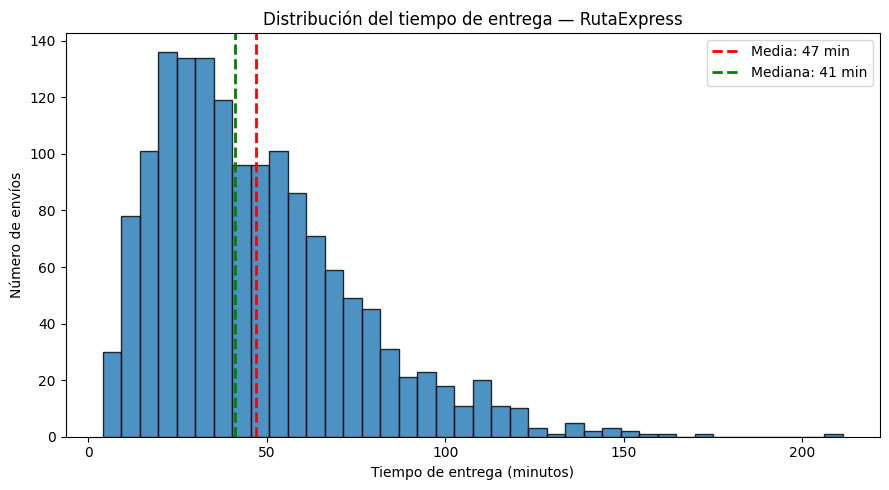

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["tiempo_entrega_min"], bins=40, color="#1f77b4", edgecolor="black", alpha=0.8)

media_tiempo = df["tiempo_entrega_min"].mean()
mediana_tiempo = df["tiempo_entrega_min"].median()
ax.axvline(media_tiempo, color="red", linestyle="--", linewidth=2, label=f"Media: {media_tiempo:,.0f} min")
ax.axvline(mediana_tiempo, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana_tiempo:,.0f} min")

ax.set_title("Distribución del tiempo de entrega — RutaExpress")
ax.set_xlabel("Tiempo de entrega (minutos)")
ax.set_ylabel("Número de envíos")
ax.legend()
plt.tight_layout()
plt.show()

> La distribución presenta una cola hacia la derecha, ya que la mayoría de los envíos se concentra en tiempos relativamente bajos, mientras que algunos envíos presentan tiempos considerablemente mayores.
Esto coincide con el sesgo positivo de 1.14 obtenido anteriormente y con que la media sea mayor que la mediana, indicando que los retrasos altos influyen en la distribución.

2. Construye, en un mismo gráfico, la densidad (KDE) de tiempo_entrega_min para dos zonas que tú elijas (por ejemplo, la de mejor y la de peor desempeño según la Parte C). ¿Qué diferencia visual encuentras entre ambas curvas, y qué decisión de negocio podrías sustentar con esa comparación?

## **Parte F — Síntesis y decisión gerencial**
1. Redacta un memo ejecutivo de máximo 200 palabras, dirigido al Director de Operaciones de RutaExpress, en el que respondas las tres preguntas planteadas en la Sección 1 (expansión de drones, zona prioritaria, meta de SLA). Cada recomendación debe estar sustentada en al menos una medida descriptiva concreta que hayas calculado (no basta con opiniones generales).


2. Menciona al menos una limitación de tu análisis que el Director debería tener en cuenta antes de tomar la decisión final (por ejemplo, relacionada con el tamaño de la muestra, variables que no están en el dataset, o el hecho de que este es solo un análisis descriptivo y no uno inferencial o causal).